# Regresión lineal con varios métodos
Este es un ejemplo muy simple del uso de dos herramientas scipy, numpy para regresión lineal.
* Numpy.polyfit
* Stats.linregress
* Optimize.curve_fit
* numpy.linalg.lstsq
* statsmodels.OLS
* Solución analítica utilizando inversa generalizada de Moore-Penrose o inversa de matriz multiplicativa simple
* sklearn.linear_model.LinearRegression

## Importando las bibliotecas

In [2]:
from scipy import linspace, polyval, polyfit, sqrt, stats, randn, optimize
import statsmodels.api as sm
import matplotlib.pyplot as plt
import time
import numpy as np
from sklearn.linear_model import LinearRegression
import pandas as pd
import pandas.testing as tm
%matplotlib inline

## Generamos datos aleatorios de un tamaño suficientemente grande

5000000
[-10.        -9.999996  -9.999992 ...   9.999992   9.999996  10.      ]
[-39.       -38.999987 -38.999974 ...  25.999974  25.999987  26.      ]


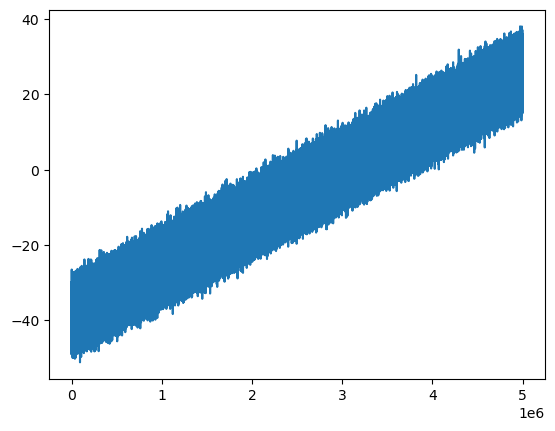

In [3]:
#Creación de datos de muestra
#número de puntos
n=int(5e6)
print(n)
t=np.linspace(-10,10,n)
print(t)
#parámetros
a=3.25; b=-6.5
x=np.polyval([a,b],t)
print(x)
#añadiendo algo de ruido
xn=x+3*np.random.randn(n)
plt.plot(xn)

### Visualizamos algunos puntos de muestra aleatorios

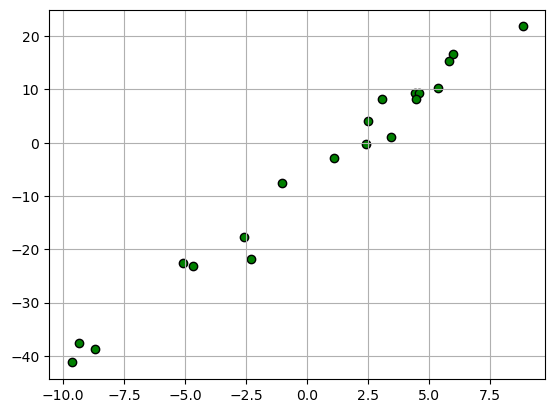

In [4]:
xvar=np.random.choice(t,size=20)
yvar=np.polyval([a,b],xvar)+3*np.random.randn(20)
plt.scatter(xvar,yvar,c='green',edgecolors='k')
plt.grid(True)
plt.show()


## Método: Numpy.Polyfit

In [5]:
#Regresión lineal -polyfit - polyfit se puede utilizar polinomios de otros órdenes
t1=time.time()
(ar,br)=np.polyfit(t,xn,1)
xr=np.polyval([ar,br],t)
#calcular el error cuadrático medio
err=np.lib.scimath.sqrt(sum((xr-xn)**2)/n)
t2=time.time()
t_polyfit = float(t2-t1)

print('Regresión Lineal usando polyfit')
print('Parámetros: a=%.2f b=%.2f, ms error= %.3f' % (ar,br,err))
print("Tiempo tomado: {} seconds".format(t_polyfit))

Regresión Lineal usando polyfit
Parámetros: a=3.25 b=-6.50, ms error= 2.999
Tiempo tomado: 1.1408281326293945 seconds


## Método: Stats.linregress

In [6]:
#Regresión Lineal usando stats.linregress
t1=time.time()
(a_s,b_s,r,tt,stderr)=stats.linregress(t,xn)
t2=time.time()
t_linregress = float(t2-t1)

print('Regresión Lineal usando stats.linregress')
print('a=%.2f b=%.2f, std error= %.3f, r^2 coefficient= %.3f' % (a_s,b_s,stderr,r))
print("Tiempo tomado: {} seconds".format(t_linregress))

Regresión Lineal usando stats.linregress
a=3.25 b=-6.50, std error= 0.000, r^2 coefficient= 0.987
Tiempo tomado: 0.11555361747741699 seconds


## Método: Optimize.curve_fit

In [7]:
def flin(t,a,b):
    result = a*t+b
    return(result)

In [8]:
t1=time.time()
p1,_=optimize.curve_fit(flin,xdata=t,ydata=xn,method='lm')
t2=time.time()
t_optimize_curve_fit = float(t2-t1)

print('Regresión Lineal usando optimize.curve_fit')
print('Parámetros: a=%.2f b=%.2f' % (p1[0],p1[1]))
print("Tiempo tomado: {} seconds".format(t_optimize_curve_fit))

Regresión Lineal usando optimize.curve_fit
Parámetros: a=3.25 b=-6.50
Tiempo tomado: 0.735952615737915 seconds


## Método: numpy.linalg.lstsq

In [9]:
t1=time.time()
A = np.vstack([t, np.ones(len(t))]).T
result = np.linalg.lstsq(A, xn,rcond=None)
ar,br = result[0]
err = np.sqrt(result[1]/len(xn))
t2=time.time()
t_linalg_lstsq = float(t2-t1)

print('Regresión Lineal usando numpy.linalg.lstsq')
print('Parámetros: a=%.2f b=%.2f, ms error= %.3f' % (ar,br,err))
print("Tiempo Tomado: {} seconds".format(t_linalg_lstsq))

Regresión Lineal usando numpy.linalg.lstsq
Parámetros: a=3.25 b=-6.50, ms error= 2.999
Tiempo Tomado: 0.10944151878356934 seconds


C:\Users\ulewi\AppData\Local\Temp\ipykernel_15536\4152585251.py:10: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print('Parámetros: a=%.2f b=%.2f, ms error= %.3f' % (ar,br,err))


## Método: Statsmodels.OLS

In [10]:
t1=time.time()
t=sm.add_constant(t)
model = sm.OLS(x, t)
results = model.fit()
ar=results.params[1]
br=results.params[0]
t2=time.time()
t_OLS = float(t2-t1)

print('Regresión Lineal usando statsmodels.OLS')
print('Parámetros: a=%.2f b=%.2f'% (ar,br))
print("Tiempo Tomado: {} seconds".format(t_OLS))

Regresión Lineal usando statsmodels.OLS
Parámetros: a=3.25 b=-6.50
Tiempo Tomado: 0.7641851902008057 seconds


In [11]:
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 1.050e+36
Date:                Mon, 19 Aug 2024   Prob (F-statistic):               0.00
Time:                        15:12:53   Log-Likelihood:             1.4704e+08
No. Observations:             5000000   AIC:                        -2.941e+08
Df Residuals:                 4999998   BIC:                        -2.941e+08
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -6.5000   1.83e-17  -3.55e+17      0.0

## Solución analítica usando pseudoinverso de Moore-Penrose

In [12]:
t1=time.time()
mpinv = np.linalg.pinv(t)
result = mpinv.dot(x)
ar = result[1]
br = result[0]
t2=time.time()
t_inv_matrix = float(t2-t1)

print('Regresión Lineal usando Moore-Penrose inverse')
print('Parámetros: a=%.2f b=%.2f'% (ar,br))
print("Tiempo Tomado: {} seconds".format(t_inv_matrix))

Regresión Lineal usando Moore-Penrose inverse
Parámetros: a=3.25 b=-6.50
Tiempo Tomado: 0.2700502872467041 seconds


## Solución analítica usando una matriz multiplicativa simple inversa

In [13]:
t1=time.time()
m = np.dot((np.dot(np.linalg.inv(np.dot(t.T,t)),t.T)),x)
ar = m[1]
br = m[0]
t2=time.time()
t_simple_inv = float(t2-t1)

print('Regresión Lineal usando simple inverse')
print('Parámetros: a=%.2f b=%.2f'% (ar,br))
print("Tiempo Tomado: {} seconds".format(t_simple_inv))

Regresión Lineal usando simple inverse
Parámetros: a=3.25 b=-6.50
Tiempo Tomado: 0.06975126266479492 seconds


## Método: sklearn.linear_model.LinearRegression

In [14]:
t1=time.time()
lm = LinearRegression()
lm.fit(t,x)
ar=lm.coef_[1]
br=lm.intercept_
t2=time.time()
t_sklearn_linear = float(t2-t1)

print('Regresión Lineal usando sklearn.linear_model.LinearRegression')
print('Parámetros: a=%.2f b=%.2f'% (ar,br))
print("Tiempo Tomado: {} seconds".format(t_sklearn_linear))

Regresión Lineal usando sklearn.linear_model.LinearRegression
Parámetros: a=3.25 b=-6.50
Tiempo Tomado: 0.36237645149230957 seconds


## Cubrimos todos los tiempos de ejecución en una lista

In [15]:
times = [t_polyfit,t_linregress,t_optimize_curve_fit,t_linalg_lstsq,t_OLS,t_inv_matrix,t_simple_inv,t_sklearn_linear]

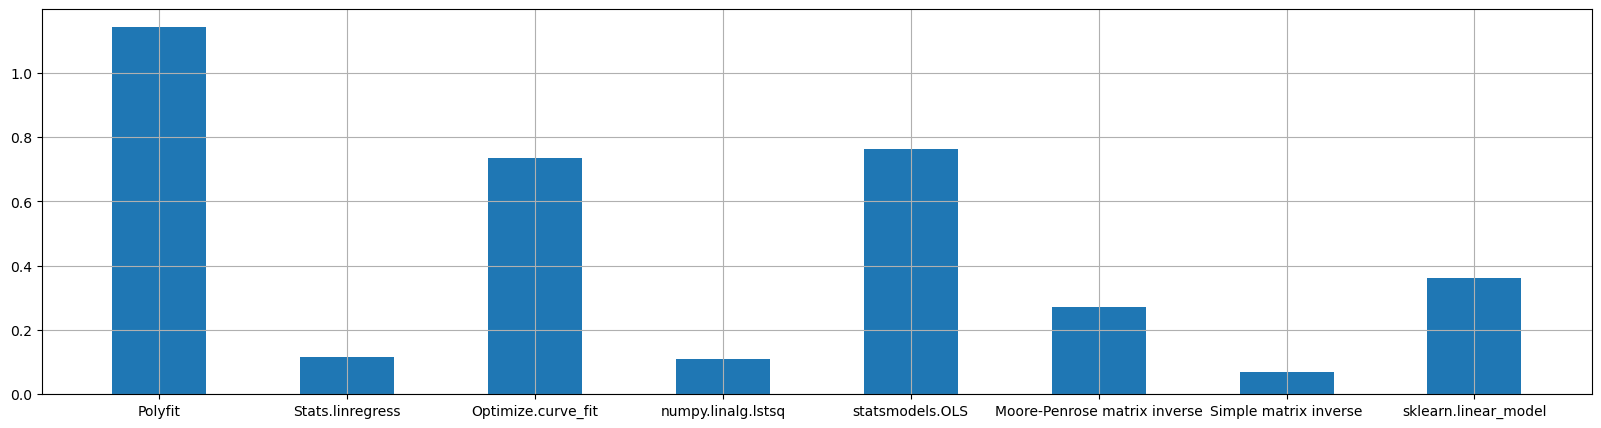

In [16]:
plt.figure(figsize=(20,5))
plt.grid(True)
plt.bar(x=[l*0.8 for l in range(8)],height=times, width=0.4,
        tick_label=['Polyfit','Stats.linregress','Optimize.curve_fit',
                    'numpy.linalg.lstsq','statsmodels.OLS','Moore-Penrose matrix inverse',
                    'Simple matrix inverse','sklearn.linear_model'])
plt.show()

In [17]:
n_min = 50000
n_max = int(1e7)
n_levels = 25
r = np.log10(n_max/n_min)
l = np.linspace(0,r,n_levels)
n_data = list((n_min*np.power(10,l)))
n_data = [int(n) for n in n_data]

In [18]:
#time_dict={'Polyfit':[],'Stats.lingress':[],'Optimize.curve_fit':[],'linalg.lstsq':[],'statsmodels.OLS':[],
          #'Moore-Penrose matrix inverse':[],'Simple matrix inverse':[], 'sklearn.linear_model':[]}

l1=['Polyfit', 'Stats.lingress','Optimize.curve_fit', 'linalg.lstsq',
 'statsmodels.OLS', 'Moore-Penrose matrix inverse', 'Simple matrix inverse', 'sklearn.linear_model']
time_dict = {key:[] for key in l1}

from tqdm import tqdm

for i in tqdm(range(len(n_data))):
    t=np.linspace(-10,10,n_data[i])
    #Parámetros
    a=3.25; b=-6.5
    x=polyval([a,b],t)
    #add some noise
    xn=x+3*randn(n_data[i])

    #Regresión Lineal usando -polyfit
    t1=time.time()
    (ar,br)=polyfit(t,xn,1)
    t2=time.time()
    t_polyfit = 1e3*float(t2-t1)
    time_dict['Polyfit'].append(t_polyfit)

    #Regresión Lineal usando stats.linregress
    t1=time.time()
    (a_s,b_s,r,tt,stderr)=stats.linregress(t,xn)
    t2=time.time()
    t_linregress = 1e3*float(t2-t1)
    time_dict['Stats.lingress'].append(t_linregress)

    #Regresión Lineal usando optimize.curve_fit
    t1=time.time()
    p1,_=optimize.curve_fit(flin,xdata=t,ydata=xn,method='lm')
    t2=time.time()
    t_optimize_curve_fit = 1e3*float(t2-t1)
    time_dict['Optimize.curve_fit'].append(t_optimize_curve_fit)

    # Regresión Lineal usando np.linalg.lstsq (solving Ax=B equation system)
    t1=time.time()
    A = np.vstack([t, np.ones(len(t))]).T
    result = np.linalg.lstsq(A, xn)
    ar,br = result[0]
    t2=time.time()
    t_linalg_lstsq = 1e3*float(t2-t1)
    time_dict['linalg.lstsq'].append(t_linalg_lstsq)

    # Regresión Lineal usando statsmodels.OLS
    t1=time.time()
    t=sm.add_constant(t)
    model = sm.OLS(x, t)
    results = model.fit()
    ar=results.params[1]
    br=results.params[0]
    t2=time.time()
    t_OLS = 1e3*float(t2-t1)
    time_dict['statsmodels.OLS'].append(t_OLS)

    # Regresión Lineal usando Moore-Penrose pseudoinverse matrix
    t1=time.time()
    mpinv = np.linalg.pinv(t)
    result = mpinv.dot(x)
    ar = result[1]
    br = result[0]
    t2=time.time()
    t_mpinverse = 1e3*float(t2-t1)
    time_dict['Moore-Penrose matrix inverse'].append(t_mpinverse)

    # Regresión Lineal usando simple multiplicative inverse matrix
    t1=time.time()
    m = np.dot((np.dot(np.linalg.inv(np.dot(t.T,t)),t.T)),x)
    ar = m[1]
    br = m[0]
    t2=time.time()
    t_simple_inv = 1e3*float(t2-t1)
    time_dict['Simple matrix inverse'].append(t_simple_inv)

    # Regresión Lineal usando scikit-learn's linear_model
    t1=time.time()
    lm = LinearRegression()
    lm.fit(t,x)
    ar=lm.coef_[1]
    br=lm.intercept_
    t2=time.time()
    t_sklearn_linear = 1e3*float(t2-t1)
    time_dict['sklearn.linear_model'].append(t_sklearn_linear)

  0%|          | 0/25 [00:00<?, ?it/s]C:\Users\ulewi\AppData\Local\Temp\ipykernel_15536\1961419488.py:14: DeprecationWarning: scipy.polyval is deprecated and will be removed in SciPy 2.0.0, use numpy.polyval instead
  x=polyval([a,b],t)
C:\Users\ulewi\AppData\Local\Temp\ipykernel_15536\1961419488.py:16: DeprecationWarning: scipy.randn is deprecated and will be removed in SciPy 2.0.0, use numpy.random.randn instead
  xn=x+3*randn(n_data[i])
C:\Users\ulewi\AppData\Local\Temp\ipykernel_15536\1961419488.py:20: DeprecationWarning: scipy.polyfit is deprecated and will be removed in SciPy 2.0.0, use numpy.polyfit instead
  (ar,br)=polyfit(t,xn,1)
C:\Users\ulewi\AppData\Local\Temp\ipykernel_15536\1961419488.py:42: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  

In [19]:
df = pd.DataFrame(data=time_dict)
df

,Polyfit,Stats.lingress,Optimize.curve_fit,linalg.lstsq,statsmodels.OLS,Moore-Penrose matrix inverse,Simple matrix inverse,sklearn.linear_model
0,16.474485,2.553225,5.778790,11.321068,36.454201,22.777319,0.529289,9.870291
1,9.825468,1.668930,7.095814,9.349823,17.795324,3.823042,0.710487,6.867886
2,10.099649,2.216339,9.359598,3.744602,13.064146,19.978285,1.015186,2.067089
3,9.121656,3.445387,12.014866,1.083374,21.983862,1.130819,0.000000,0.000000
4,0.000000,15.609026,0.000000,15.617132,17.235041,1.015663,0.000000,0.000000
5,13.045311,0.000000,15.635967,15.632629,16.108751,15.637636,0.000000,15.798330
6,16.025782,0.000000,34.668922,0.000000,31.754017,15.260935,3.720284,14.559269
7,15.780210,3.733635,32.120466,0.000000,32.119989,18.051386,0.000000,15.656710
8,16.930819,16.932726,49.125910,1.274586,46.161652,15.641212,0.000000,21.386623
9,15.655756,0.000000,76.160192,17.435789,82.457066,15.515804,0.000000,42.214394


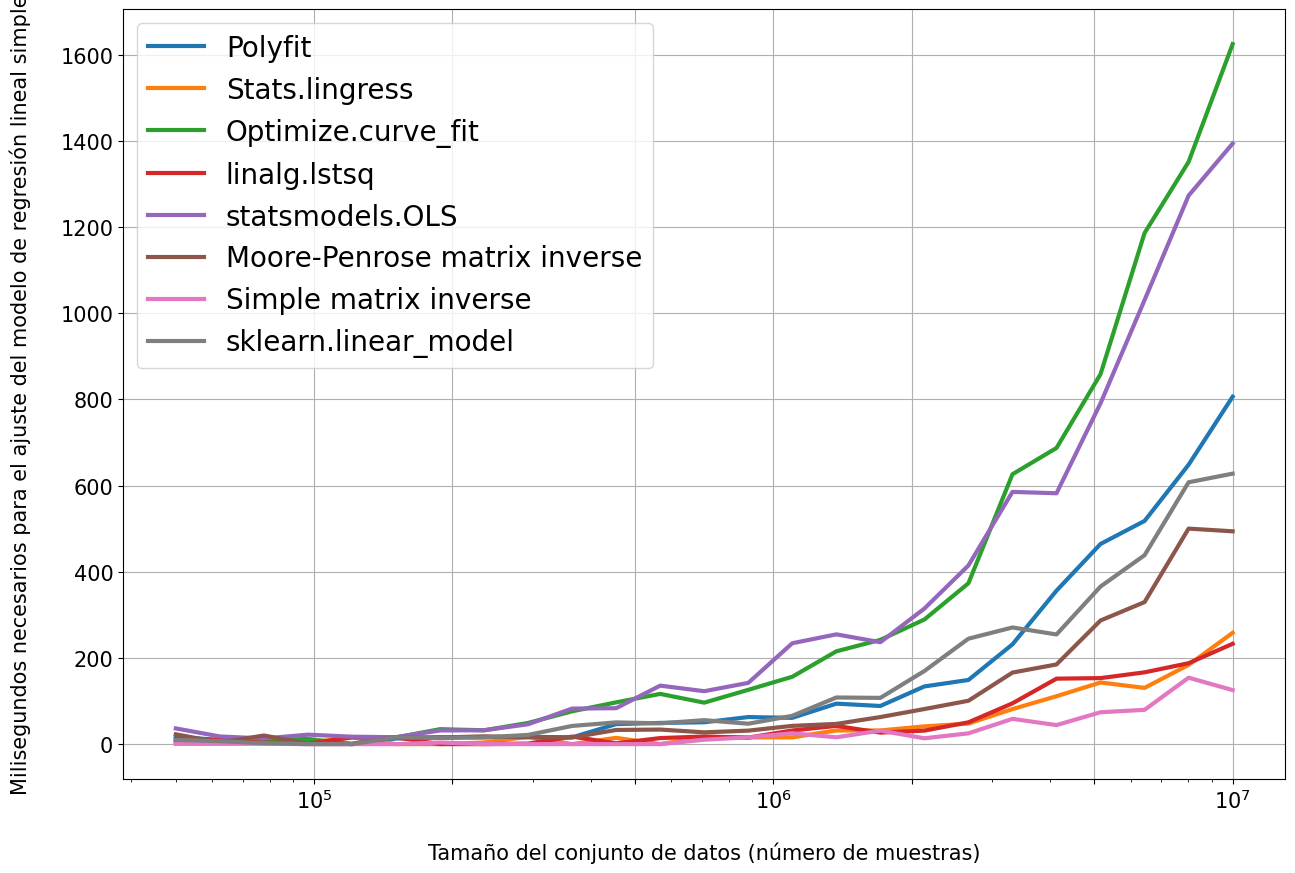

In [20]:
plt.figure(figsize=(15,10))
for i in df.columns:
    plt.semilogx((n_data),df[i],lw=3)
plt.xticks([1e5,2e5,5e5,1e6,2e6,5e6,1e7],fontsize=15)
plt.xlabel("\nTamaño del conjunto de datos (número de muestras)",fontsize=15)
plt.yticks(fontsize=15)
plt.ylabel("Milisegundos necesarios para el ajuste del modelo de regresión lineal simple\n",fontsize=15)
plt.grid(True)
plt.legend([name for name in df.columns],fontsize=20)

In [21]:
a1=df.iloc[n_levels-1]

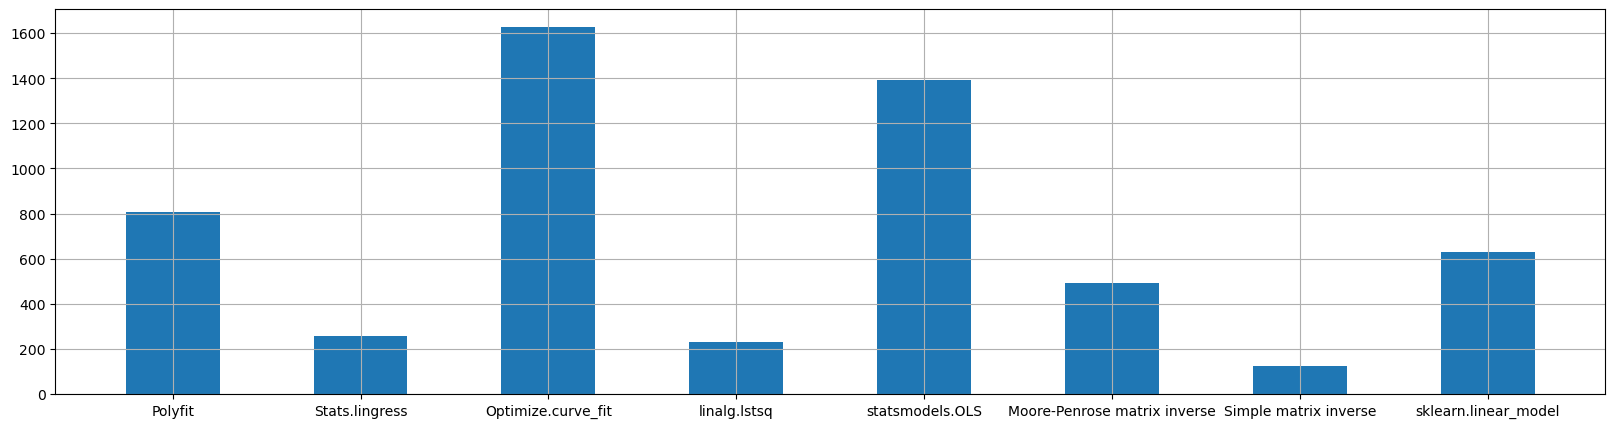

In [22]:
plt.figure(figsize=(20,5))
plt.grid(True)
plt.bar(x=[l*0.8 for l in range(8)],height=a1, width=0.4,
        tick_label=list(a1.index))
plt.show()